<h3>Classification d'Images avec Data Augmentation (Random Erasing)<h3/>

In [25]:
###========================================================================
# Importations et Configuration
###========================================================================

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import datasets, transforms
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import sys
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Configuration de l'appareil
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil: {device}")

Utilisation de l'appareil: cpu


In [ ]:
###========================================================================
# Transformation de Base (Normalisation)
###========================================================================

# Transformation de base : Redimensionnement, ToTensor, Normalisation
BASE_TRANSFORM = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Charger les données avec ImageFolder et la transformation de base
dataset = datasets.ImageFolder(root="data_img", transform=BASE_TRANSFORM)
data_loader = DataLoader(dataset, batch_size=32, shuffle=True) #  nb_batch = nb_data / 32

print("Classes:", dataset.classes)
print("Index des classes:", dataset.class_to_idx)

Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'ragno', 'sheep', 'squirrel']
Index des classes: {'butterfly': 0, 'cat': 1, 'chicken': 2, 'cow': 3, 'dog': 4, 'elephant': 5, 'horse': 6, 'ragno': 7, 'sheep': 8, 'squirrel': 9}


In [41]:
###========================================================================
# Sélection d'un Échantillon (Sous-échantillonnage)
###========================================================================

from collections import defaultdict

# --- Configuration ---
# Remplacez 'dataset' et 'data_loader' par vos objets PyTorch respectifs
# dataset = datasets.ImageFolder(root="data_img", transform=BASE_TRANSFORM) 
# data_loader = DataLoader(dataset, batch_size=32, shuffle=True) 

max_images_per_class = 1000 
num_classes = len(dataset.classes) # Nombre total de classes

# Dictionnaires pour stocker les images et labels
class_images = defaultdict(list)
class_labels = defaultdict(list)

print(f"Collecte de {max_images_per_class} images par classe...")

# --- Logique de Collecte Optimisée ---
# Utilise un ensemble (set) pour un look-up rapide
classes_to_collect = set(range(num_classes))
classes_finished = set()

for images, labels in data_loader:
    # Parcourir les images du lot
    for image, label in zip(images, labels):
        label_item = label.item()
        
        # Vérifier si on a déjà atteint la limite pour cette classe
        if label_item in classes_finished:
            continue
            
        # Ajouter l'image et le label
        class_images[label_item].append(image)
        class_labels[label_item].append(label_item)
        
        # Vérifier si la classe a atteint sa limite
        if len(class_images[label_item]) >= max_images_per_class:
            classes_finished.add(label_item)
            
    # Condition d'arrêt : Vérification après le lot
    if len(classes_finished) == num_classes:
        break

# --- Vérification Finale (Non nécessaire avec la logique ci-dessus, mais gardée par sécurité) ---
# S'assure que toutes les listes ne dépassent pas max_images_per_class
for class_idx in class_images:
    class_images[class_idx] = class_images[class_idx][:max_images_per_class]
    class_labels[class_idx] = class_labels[class_idx][:max_images_per_class]

# --- Affichage Final ---
print("\nNombre d'images par classe après sous-échantillonnage :")
for class_idx in sorted(class_images.keys()):
    count = len(class_images[class_idx])
    print(f"Classe {dataset.classes[class_idx]} : {count} images")

if len(classes_finished) < num_classes:
    print(f"\n Avertissement: Seulement {len(classes_finished)}/{num_classes} classes ont atteint {max_images_per_class} images (la fin du dataset a été atteinte).")

Collecte de 1000 images par classe...

Nombre d'images par classe après sous-échantillonnage :
Classe butterfly : 1000 images
Classe cat : 1000 images
Classe chicken : 1000 images
Classe cow : 1000 images
Classe dog : 1000 images
Classe elephant : 1000 images
Classe horse : 1000 images
Classe ragno : 1000 images
Classe sheep : 1000 images
Classe squirrel : 1000 images


In [42]:
# Définition des Datasets pour l'Augmentation
###========================================================================
# Classes de Dataset pour la Manipulation de Tenseurs
###========================================================================

class SubsetTensorDataset(Dataset):
    """Encapsule les tenseurs d'images collectés et normalisés."""
    def __init__(self, class_images, class_labels):
        self.images = []
        self.labels = []
        for label, images in class_images.items():
            self.images.extend(images)
            self.labels.extend([label] * len(images))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

class AugmentedSubset(Dataset):
    """Applique une transformation spécifique (e.g., RandomErasing) à un Subset."""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            # Application de la transformation (Random Erasing) sur le tenseur
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [43]:
###========================================================================
# Division et Application de Random Erasing
###========================================================================

# Définition de Random Erasing (Suppression de zone)
# Il ne fait que la suppression de zone, car les autres étapes sont déjà faites.
RANDOM_ERASING_TRANSFORM = transforms.RandomErasing(
    p=0.5,           # 50% de chance d'appliquer la suppression
    scale=(0.02, 0.33), # Taille de la zone
    ratio=(0.3, 3.3),   # Ratio H/L
    value='random'   # Remplir la zone avec des valeurs aléatoires
)

# Créer le dataset de base avec les tenseurs collectés
base_dataset = SubsetTensorDataset(class_images, class_labels)

# Division en Train (80%) et Validation (20%)
train_size = int(0.8 * len(base_dataset))
valid_size = len(base_dataset) - train_size
train_indices, valid_indices = random_split(base_dataset, [train_size, valid_size])

# Création des datasets finaux
# train_dataset reçoit RandomErasing
train_dataset = AugmentedSubset(train_indices, transform=RANDOM_ERASING_TRANSFORM)
# valid_dataset ne reçoit aucune transformation additionnelle
valid_dataset = AugmentedSubset(valid_indices, transform=None)

# Création des DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False) # Pas besoin de mélanger la validation

print(f"Taille du jeu d'entraînement (avec Random Erasing): {len(train_dataset)}")
print(f"Taille du jeu de validation: {len(valid_dataset)}")

Taille du jeu d'entraînement (avec Random Erasing): 8000
Taille du jeu de validation: 2000


In [44]:
###========================================================================
# Visualisation de l'Augmentation
###========================================================================

# Définition de la fonction de dénormalisation (imshow)
def imshow(img, title=None):
    """Dé-normalise et affiche une image (tenseur PyTorch)"""
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    
    # Dé-normalisation
    img = img.numpy().transpose((1, 2, 0)) # C, H, W -> H, W, C
    img = std * img + mean
    img = np.clip(img, 0, 1) 
    
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# ----------------------------------------------------------------------

def visualize_augmentation(base_dataset, train_dataset, class_id=None, image_index_in_class=None):
    """
    Visualise une image spécifique du jeu de données, avec et sans Random Erasing.

    Args:
        base_dataset (Dataset): Votre SubsetTensorDataset contenant tous les tenseurs.
        train_dataset (Dataset): Votre AugmentedSubset du jeu d'entraînement.
        class_id (int, optional): L'ID de la classe à visualiser.
        image_index_in_class (int, optional): L'index de l'image DANS cette classe.
    """
    
    # 1. Préparation des indices d'accès par classe
    # Trouver tous les index du base_dataset pour chaque classe
    class_indices = defaultdict(list)
    for idx, (img, label) in enumerate(base_dataset):
        class_indices[label].append(idx)

    # 2. Sélection de la classe et de l'index
    
    # Si aucune classe n'est spécifiée, choisir une classe aléatoirement
    if class_id is None:
        class_id = random.choice(list(class_indices.keys()))
    
    # Vérifier si la classe sélectionnée a des images
    if class_id not in class_indices:
        print(f"La classe {class_id} n'a pas été trouvée dans le base_dataset.")
        return

    # Si aucun index n'est spécifié, choisir un index aléatoirement
    if image_index_in_class is None:
        image_index_in_class = random.randrange(len(class_indices[class_id]))

    # Récupérer l'index GLOBAL dans le base_dataset
    try:
        global_index = class_indices[class_id][image_index_in_class]
    except IndexError:
        print(f"L'indice {image_index_in_class} est hors limites pour la classe {class_id} (max {len(class_indices[class_id])-1}).")
        return

    # 3. Extraction et Augmentation
    
    # Image originale (sans augmentation) directement du base_dataset
    # Cette image est le TENSEUR NORMALISÉ ET NON AUGMENTÉ
    image_orig, label_idx = base_dataset[global_index]
    
    # Image augmentée : Nous devons simuler la transformation RandomErasing
    # en l'appliquant manuellement sur l'image originale.
    # Note: On utilise RANDOM_ERASING_TRANSFORM défini précédemment.
    image_aug = RANDOM_ERASING_TRANSFORM(image_orig.clone())

    # 4. Affichage
    
    # Assurez-vous d'avoir accès à 'dataset.classes' pour les noms
    # Si vous n'avez pas dataset.classes, utilisez la ligne commentée ci-dessous
    class_name = dataset.classes[label_idx] if 'dataset' in globals() and hasattr(dataset, 'classes') else f"Classe {label_idx}"
    
    print(f"Visualisation de l'image [Index local: {image_index_in_class}, Index global: {global_index}] de la classe '{class_name}':")

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    plt.sca(axes[0])
    imshow(image_orig.cpu(), title=f"Original - {class_name}")

    plt.sca(axes[1])
    imshow(image_aug.cpu(), title=f"Augmentée (Random Erasing) - {class_name}")

    plt.tight_layout()
    plt.show()


--- 1. Exemple Aléatoire ---
Visualisation de l'image [Index local: 627, Index global: 9627] de la classe 'elephant':


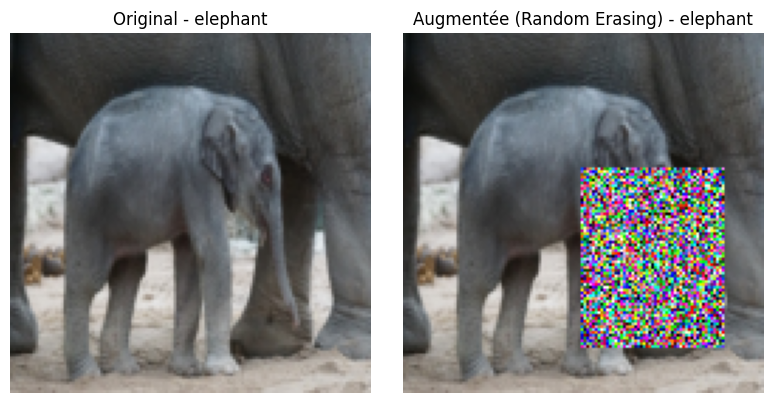

In [65]:
# --- APPEL ---

# 1. Sélection Aléatoire (par défaut)
print("--- 1. Exemple Aléatoire ---")
visualize_augmentation(base_dataset, train_dataset) 

# 2. Sélection Spécifique (Classe 0, 3e image)
# Assurez-vous que la classe 0 et l'indice 2 existent
#print("--- 2. Exemple Spécifique (Classe 0, 3e image) ---")
#visualize_augmentation(base_dataset, train_dataset, class_id=0, image_index_in_class=2)

In [47]:
###========================================================================
# Définition du Modèle 
###========================================================================

class CNN_Animals(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        # Taille d'entrée pour la FC: 128x128 -> (pool x3) -> 16x16
        self.fc1 = nn.Linear(64 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = CNN_Animals(num_classes=len(dataset.classes)).to(device)
print(model)

CNN_Animals(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [48]:
# Modèle CNN et Fonctions d'Entraînement/Test
###========================================================================
# Boucles d'Entraînement et de Test
###========================================================================

def train_loop(loader, model, loss_fn, optimizer, log=True):
    model.train()
    total_loss = 0
    size = len(loader.dataset)

    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)

        # Forward
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if log and batch % 10 == 0:
            current = (batch + 1) * len(X)
            # batch_size_actual = len(X) # Taille réelle du lot # [Taille lot: {batch_size_actual:>2d}]
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")
            

    avg_loss = total_loss / len(loader)
    print(f"🔹 Moyenne de la loss sur l'époque : {avg_loss:.4f}")
    return avg_loss

def test_loop(loader, model, loss_fn, log=True):
    model.eval()
    size = len(loader.dataset)
    num_batches = len(loader)
    test_loss, correct = 0, 0

    # Listes pour collecter toutes les prédictions et tous les labels
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            # Collecte des prédictions et des labels
            predictions = pred.argmax(1)
            correct += (predictions == y).type(torch.float).sum().item()

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    test_loss /= num_batches
    accuracy = correct / size

    # 🔑 Calcul des métriques avancées avec scikit-learn
    
    # Le mode 'macro' traite toutes les classes avec le même poids (utile pour les classes déséquilibrées)
    # Le mode 'weighted' pondère les scores par le nombre d'échantillons de chaque classe
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    
    # 🔑 Génération de la Matrice de Confusion
    conf_matrix = confusion_matrix(all_labels, all_preds)

    if log:
        print(f"Test Error: \n Accuracy: {(100 * accuracy):>0.1f}%, loss: {test_loss:>8f} ")
        print("-" * 30)
        print(f"Metrics (Macro Avg.):")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1 Score:  {f1:.4f}")
        print("-" * 30)
        # Vous pouvez aussi afficher la matrice de confusion à la fin de l'entraînement
        # print("Matrice de Confusion:\n", conf_matrix)
        
    # Retourne la loss, l'accuracy et le score F1 macro
    return test_loss, 100 * accuracy, f1

In [50]:
###========================================================================
# Entraînement Final et Tracé des Résultats
###========================================================================

epochs = 6 
loss_test = []
loss_train = []
acc_test = []
f1_test = []

if 'model' in locals():
    del model
    print("model supp")


model = CNN_Animals(num_classes=len(dataset.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for t in range(epochs):
    print(f"\n===== Époque {t+1} =====")
    # Entraînement avec data augmentation
    loss_train.append(train_loop(train_loader, model, loss_fn, optimizer))
    # Évaluation sans data augmentation (loss, accuracy, f1_score)
    l, a, f = test_loop(valid_loader, model, loss_fn) 
    loss_test.append(l)
    acc_test.append(a)
    f1_test.append(f)
print("Done!")

model supp

===== Époque 1 =====
loss: 2.300953  [   32/ 8000]
loss: 2.302085  [  352/ 8000]
loss: 2.293755  [  672/ 8000]
loss: 2.162191  [  992/ 8000]
loss: 2.195722  [ 1312/ 8000]
loss: 2.203112  [ 1632/ 8000]
loss: 2.058940  [ 1952/ 8000]
loss: 2.240318  [ 2272/ 8000]
loss: 2.210655  [ 2592/ 8000]
loss: 2.141478  [ 2912/ 8000]
loss: 2.166127  [ 3232/ 8000]
loss: 1.910862  [ 3552/ 8000]
loss: 2.042769  [ 3872/ 8000]
loss: 1.997272  [ 4192/ 8000]
loss: 1.869538  [ 4512/ 8000]
loss: 1.844239  [ 4832/ 8000]
loss: 1.996372  [ 5152/ 8000]
loss: 2.065827  [ 5472/ 8000]
loss: 2.004584  [ 5792/ 8000]
loss: 1.983666  [ 6112/ 8000]
loss: 1.886658  [ 6432/ 8000]
loss: 1.987419  [ 6752/ 8000]
loss: 1.995642  [ 7072/ 8000]
loss: 2.069841  [ 7392/ 8000]
loss: 1.881333  [ 7712/ 8000]
🔹 Moyenne de la loss sur l'époque : 2.0945
Test Error: 
 Accuracy: 33.2%, loss: 1.900442 
------------------------------
Metrics (Macro Avg.):
  Precision: 0.3777
  Recall:    0.3294
  F1 Score:  0.3165
--------------

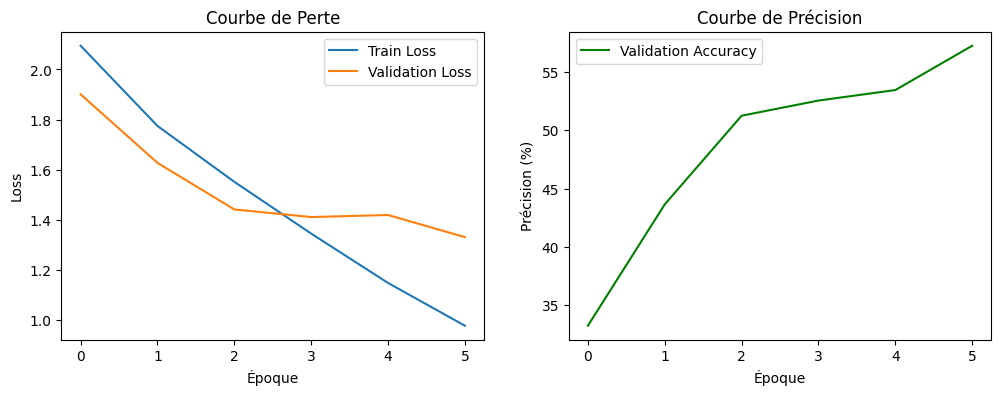

In [51]:
# Tracé des courbes
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_train, label='Train Loss')
plt.plot(loss_test, label='Validation Loss')
plt.title('Courbe de Perte')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_test, label='Validation Accuracy', color='green')
plt.title("Courbe de Précision")
plt.xlabel('Époque')
plt.ylabel('Précision (%)')
plt.legend()
plt.show()

In [63]:
print("Init: ", loss_test[0], "   Final: ", loss_test[len(loss_test)-1])
print("Init: ", acc_test[0], "                Final: ", acc_test[len(acc_test)-1], "%")
print("Init: ", f1_test[0], "   Final: ", f1_test[len(f1_test)-1])

Init:  1.9004420023115853    Final:  1.3306789152205936
Init:  33.25                 Final:  57.25 %
Init:  0.3164713395728083    Final:  0.5763834560256109
